# Cause ablation (full dataset): why did validation DockQ MSE stop rising?

The feature ladder's validation DockQ MSE was best at epoch 1--2 and then rose; the anti-memorization
control **A** did not rise. A differed from the ladder recipe **L** in five training settings. This experiment
switches them one at a time in both directions: each `L_plus_*` adds one A setting to L, each `A_minus_*`
removes one from A (design: `CAUSE_ABLATION_FULL.md`). A is reused from `anti_memorization_full`.

| setting | L (ladder) | A (control) |
|---|---|---|
| loss weighting | adaptive shares | fixed, reconstruction $\lambda=1$ |
| DockQ range weighting | none | capped inverse-sqrt, $\alpha=0.5$ |
| pooling | whole graph | whole + interface |
| dropout | 0.1 | 0.3 |
| cosine schedule | 50 epochs | 20 epochs |

A setting is implicated when adding it to L removes the rise **and** removing it from A brings the rise
back. Every run uses the same measurement (validation every 2,000 steps and at epoch ends, exact
graph-average MSE, best-step checkpoint); the test split is not touched.

**Partial runs are handled explicitly.** A run still training contributes its validation history so far.
The main comparisons use a **common horizon**: the number of epochs every run has completed (printed below).
Full 20-epoch numbers and checkpoint-quality metrics use finished runs only. The prose in the final section
quotes the numbers from the analysis with 26/27 runs finished (A $-$ combined pool seed 27 at epoch 18 of 20).

Figures use LaTeX Computer Modern, large labels, full borders and no titles. Spreads are SD over seeds;
effects are paired by seed.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

GATE = Path.cwd() if (Path.cwd() / 'cause_ablation_full').is_dir() else Path.cwd() / 'gate_run'
ROOT = GATE / 'cause_ablation_full'
CONTROL_ROOT = GATE / 'anti_memorization_full'
EXPORT = GATE / 'cause_ablation_full_analysis'; EXPORT.mkdir(exist_ok=True)
EPOCHS, BATCH = 20, 16
SEEDS = [7, 17, 27]

CONFIG = pd.DataFrame([
    # name               weighting range  pooling     dropout schedule
    ('L_ladder',         'shares', 'none', 'whole',    0.1, 50),
    ('L_plus_fixed',     'fixed',  'none', 'whole',    0.1, 50),
    ('L_plus_dropout',   'shares', 'none', 'whole',    0.3, 50),
    ('L_plus_sched20',   'shares', 'none', 'whole',    0.1, 20),
    ('A_minus_fixed',    'shares', 'none', 'combined', 0.3, 20),
    ('A_minus_dropout',  'fixed',  'inv',  'combined', 0.1, 20),
    ('A_minus_sched',    'fixed',  'inv',  'combined', 0.3, 50),
    ('A_minus_range',    'fixed',  'none', 'combined', 0.3, 20),
    ('A_minus_combined', 'fixed',  'inv',  'whole',    0.3, 20),
    ('A_control',        'fixed',  'inv',  'combined', 0.3, 20),
], columns=['config', 'weighting', 'range', 'pooling', 'dropout', 'schedule']).set_index('config')
CONFIGS = list(CONFIG.index)
LABEL = {'L_ladder': 'L (ladder)', 'L_plus_fixed': 'L + fixed', 'L_plus_dropout': 'L + dropout 0.3',
         'L_plus_sched20': 'L + 20-ep schedule', 'A_minus_fixed': 'A $-$ fixed', 'A_minus_dropout': 'A $-$ dropout',
         'A_minus_sched': 'A, 50-ep schedule', 'A_minus_range': 'A $-$ range wt.',
         'A_minus_combined': 'A $-$ combined pool', 'A_control': 'A (control)'}
COLOR = {'L_ladder': '#7f7f7f', 'L_plus_fixed': '#0072B2', 'L_plus_dropout': '#009E73', 'L_plus_sched20': '#CC79A7',
         'A_minus_fixed': '#0072B2', 'A_minus_dropout': '#009E73', 'A_minus_sched': '#CC79A7',
         'A_minus_range': '#D55E00', 'A_minus_combined': '#E69F00', 'A_control': '#000000'}

mpl.rcParams.update({'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern Roman'],
    'mathtext.fontset': 'cm', 'axes.labelsize': 23, 'xtick.labelsize': 17, 'ytick.labelsize': 17,
    'legend.fontsize': 17, 'axes.spines.top': True, 'axes.spines.right': True, 'axes.linewidth': 1.1})

def save(fig, name):
    fig.savefig(EXPORT / (name + '.pdf'), bbox_inches='tight')
    fig.savefig(EXPORT / (name + '.png'), dpi=180, bbox_inches='tight')
    plt.show()

def run_dir(config, seed):
    return (CONTROL_ROOT if config == 'A_control' else ROOT) / f'{config}_seed{seed}'

steps, history, status, predictions = [], [], [], {}
for config in CONFIGS:
    for seed in SEEDS:
        d = run_dir(config, seed)
        if not (d / 'validation_steps.csv').exists() or not (d / 'loss_history.csv').exists():
            status.append(dict(config=config, seed=seed, epochs_done=0, complete=False)); continue
        s = pd.read_csv(d / 'validation_steps.csv').assign(config=config, seed=seed)
        h = pd.read_csv(d / 'loss_history.csv').assign(config=config, seed=seed)
        complete = (h.epoch.max() == EPOCHS) and (d / 'validation_predictions.csv').exists()
        if complete:
            predictions[config, seed] = pd.read_csv(d / 'validation_predictions.csv')
            mse = np.mean((predictions[config, seed].predicted_target - predictions[config, seed].true_target) ** 2)
            if not np.isclose(mse, s.val_target_mse.min(), rtol=1e-5, atol=1e-7):
                raise ValueError(f'{config} seed {seed}: exported predictions are not the best validation')
        steps.append(s); history.append(h)
        status.append(dict(config=config, seed=seed, epochs_done=int(h.epoch.max()), validations=len(s),
                           complete=complete))
steps = pd.concat(steps, ignore_index=True); history = pd.concat(history, ignore_index=True)
status = pd.DataFrame(status)
steps['graphs_seen_M'] = steps.global_step * BATCH / 1e6
# Training-set size from the step count of a full epoch (identical cohort for every run).
steps_per_epoch = int(steps[(steps.end_of_epoch == 1) & (steps.epoch == 1)].global_step.mode().iloc[0])

reference = next(iter(predictions.values()))[['target_id', 'graph_name', 'true_target']]
for key, p in predictions.items():
    if not (p.graph_name.equals(reference.graph_name) and np.allclose(p.true_target, reference.true_target)):
        raise ValueError(f'{key}: validation cohort differs')
CONST_MSE = reference.true_target.var(ddof=0)
HORIZON = int(status.epochs_done.min())
new = status[status.config != 'A_control']
done = int(new.complete.sum())
print(f'{done}/{len(new)} ablation runs complete (plus the 3 reused control runs); common horizon = {HORIZON} epochs '
      f'({steps_per_epoch} steps/epoch, {steps_per_epoch * BATCH:,} graphs/epoch approx.).')
print(f'Completed runs share one validation cohort ({len(reference):,} decoys); constant-predictor MSE {CONST_MSE:.4f}.')
display(status.pivot(index='config', columns='seed', values='epochs_done').loc[CONFIGS])

26/27 ablation runs complete (plus the 3 reused control runs); common horizon = 18 epochs (7988 steps/epoch, 127,808 graphs/epoch approx.).
Completed runs share one validation cohort (14,155 decoys); constant-predictor MSE 0.0903.


seed,7,17,27
config,,,
L_ladder,20,20,20
L_plus_fixed,20,20,20
L_plus_dropout,20,20,20
L_plus_sched20,20,20,20
A_minus_fixed,20,20,20
A_minus_dropout,20,20,20
A_minus_sched,20,20,20
A_minus_range,20,20,20
A_minus_combined,20,20,18


## Metrics at the common horizon

For each run, using only validations up to the end of the common-horizon epoch:

- **best**: lowest validation MSE (what checkpointing would keep),
- **late**: mean of all validations in the last two horizon epochs (a noise-robust "where it is now"),
- **rise** = late $-$ best (how far it has climbed back from its best).

Full-length versions (20 epochs) are computed for finished runs only.

In [2]:
def window_metrics(s, last_epoch):
    s = s[s.epoch <= last_epoch].sort_values('global_step')
    b = s.loc[s.val_target_mse.idxmin()]
    late = s[s.epoch > last_epoch - 2].val_target_mse.mean()
    return dict(best=b.val_target_mse, best_epoch=int(b.epoch), late=late, rise=late - b.val_target_mse)

rows = []
for (config, seed), s in steps.groupby(['config', 'seed']):
    h = history[(history.config == config) & (history.seed == seed)]
    row = dict(config=config, seed=seed, **window_metrics(s, HORIZON),
               train_mse_h=h[h.epoch == HORIZON].train_target_mse.iloc[0],
               dockq_weight_h=h[h.epoch == HORIZON].weight_target_mse.iloc[0])
    st = status[(status.config == config) & (status.seed == seed)].iloc[0]
    if st.complete:
        full = window_metrics(s, EPOCHS)
        row.update({f'{k}_full': v for k, v in full.items()}, train_mse_full=h.train_target_mse.iloc[-1])
    rows.append(row)
metrics = pd.DataFrame(rows)
metrics['config'] = pd.Categorical(metrics.config, CONFIGS, ordered=True)
metrics = metrics.sort_values(['config', 'seed']).reset_index(drop=True)
metrics.to_csv(EXPORT / 'metrics_per_run.csv', index=False)

agg = metrics.groupby('config', observed=True).agg(
    n=('seed', 'size'), best=('best', 'mean'), best_sd=('best', 'std'), late=('late', 'mean'),
    late_sd=('late', 'std'), rise=('rise', 'mean'), best_epoch=('best_epoch', 'mean'),
    late_full=('late_full', 'mean'), n_full=('late_full', 'count'), train_mse_h=('train_mse_h', 'mean'))
agg = CONFIG.join(agg)
agg.to_csv(EXPORT / 'metrics_by_config.csv')
display(agg.round(4))

,weighting,range,pooling,dropout,schedule,n,best,best_sd,late,late_sd,rise,best_epoch,late_full,n_full,train_mse_h
config,,,,,,,,,,,,,,,
L_ladder,shares,none,whole,0.1,50,3,0.0552,0.0020,0.1144,0.0026,0.0592,1.3333,0.1173,3,0.0042
L_plus_fixed,fixed,none,whole,0.1,50,3,0.0524,0.0029,0.0927,0.0031,0.0403,2.3333,0.0944,3,0.0116
L_plus_dropout,shares,none,whole,0.3,50,3,0.0641,0.0043,0.0958,0.0033,0.0317,3.6667,0.1001,3,0.0112
L_plus_sched20,shares,none,whole,0.1,20,3,0.0582,0.0079,0.1169,0.0044,0.0587,1.0000,0.1174,3,0.0039
A_minus_fixed,shares,none,combined,0.3,20,3,0.0512,0.0029,0.0879,0.0024,0.0367,1.0000,0.0876,3,0.0099
A_minus_dropout,fixed,inv,combined,0.1,20,3,0.0515,0.0026,0.0740,0.0062,0.0225,2.0000,0.0736,3,0.0125
A_minus_sched,fixed,inv,combined,0.3,50,3,0.0475,0.0022,0.0570,0.0052,0.0095,8.6667,0.0564,3,0.0257
A_minus_range,fixed,none,combined,0.3,20,3,0.0482,0.0016,0.0630,0.0017,0.0148,5.0000,0.0626,3,0.0238
A_minus_combined,fixed,inv,whole,0.3,20,3,0.0498,0.0007,0.0541,0.0025,0.0042,7.3333,0.0553,2,0.0263


## Validation curves

One panel per ablated configuration: its seeds (thin) and their mean (thick, drawn only where all three seeds
have data), against the means of L (grey dashed) and A (black). Runs still training simply end early. The
dotted vertical line marks the common horizon.

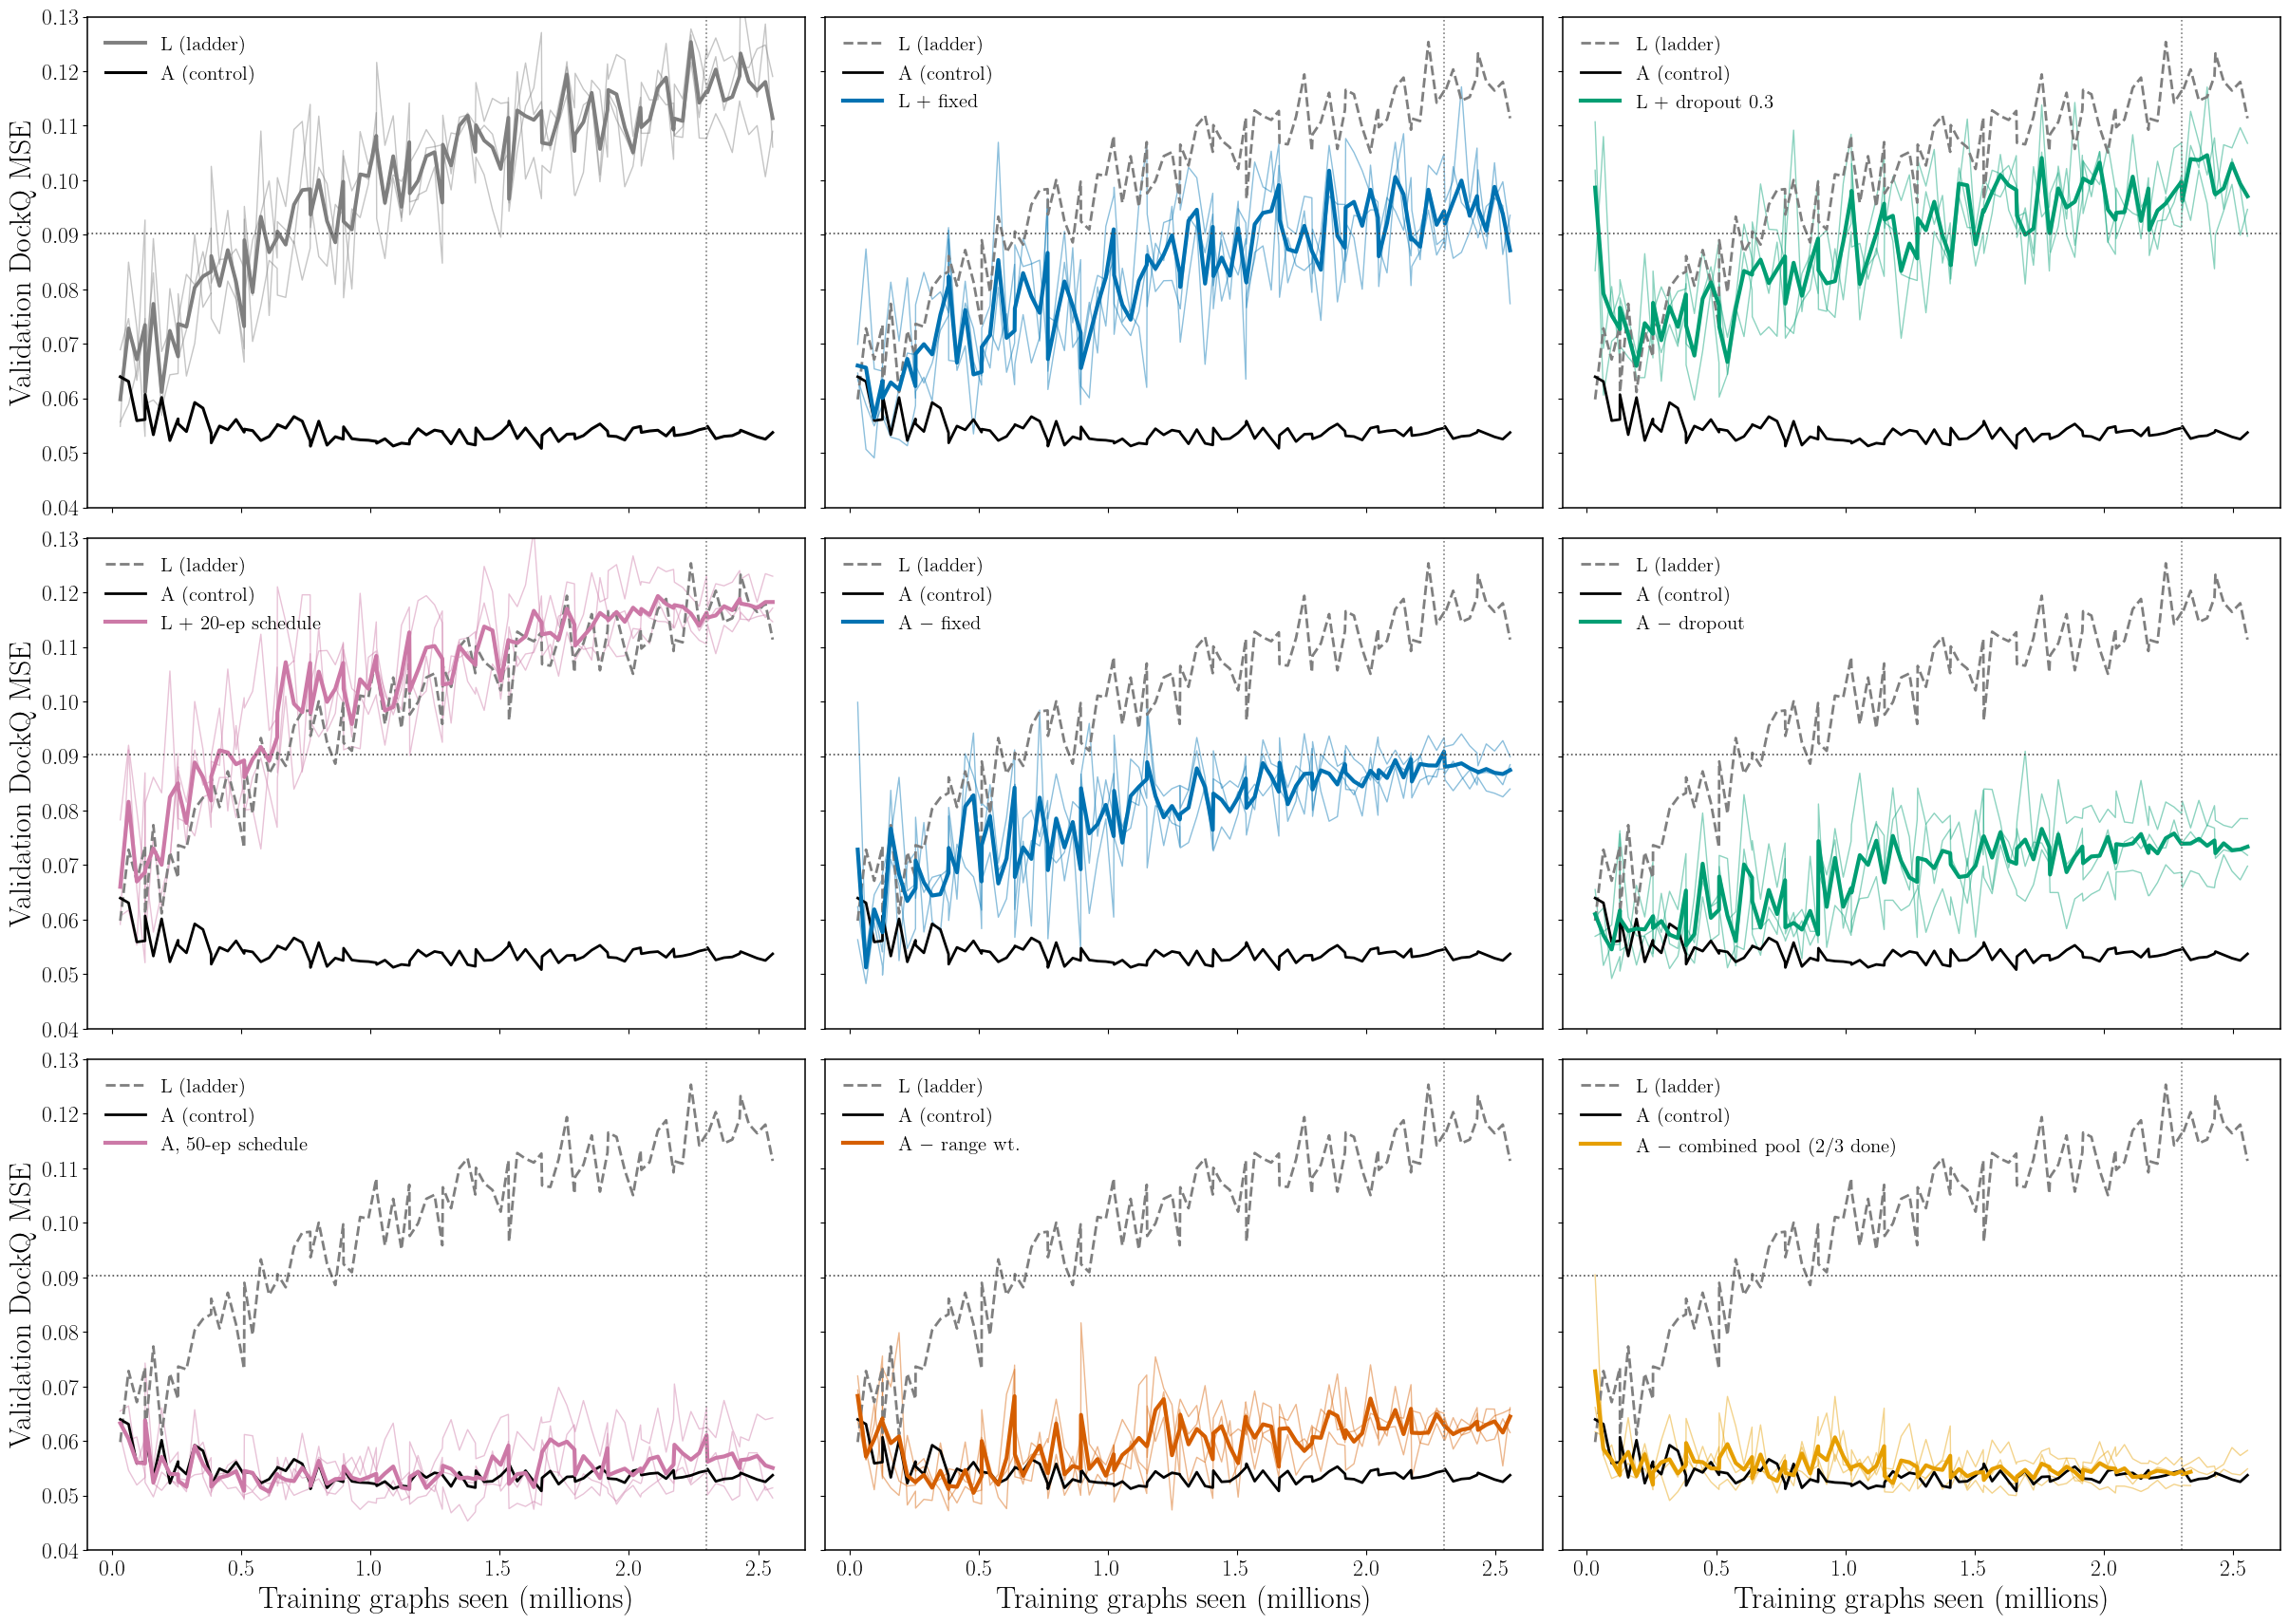

In [3]:
def mean_curve(config):
    s = steps[steps.config == config]
    g = s.groupby('global_step').agg(x=('graphs_seen_M', 'first'), y=('val_target_mse', 'mean'), n=('seed', 'nunique'))
    return g[g.n == s.seed.nunique()]

L, A = mean_curve('L_ladder'), mean_curve('A_control')
xh = HORIZON * steps_per_epoch * BATCH / 1e6
panel_configs = [c for c in CONFIGS if c not in ('L_ladder', 'A_control')]
fig, axes = plt.subplots(3, 3, figsize=(24, 17), sharex=True, sharey=True, constrained_layout=True)
axes.flat[0].plot(L.x, L.y, color=COLOR['L_ladder'], lw=2.8, label=LABEL['L_ladder'])
for seed in SEEDS:
    s = steps[(steps.config == 'L_ladder') & (steps.seed == seed)].sort_values('global_step')
    axes.flat[0].plot(s.graphs_seen_M, s.val_target_mse, color=COLOR['L_ladder'], lw=1, alpha=.45)
axes.flat[0].plot(A.x, A.y, color='black', lw=2.2, label=LABEL['A_control'])
for ax, config in zip(axes.flat[1:], panel_configs):
    for seed in SEEDS:
        s = steps[(steps.config == config) & (steps.seed == seed)].sort_values('global_step')
        ax.plot(s.graphs_seen_M, s.val_target_mse, color=COLOR[config], lw=1, alpha=.45)
    m = mean_curve(config)
    ax.plot(L.x, L.y, color=COLOR['L_ladder'], lw=2, ls='--', label=LABEL['L_ladder'])
    ax.plot(A.x, A.y, color='black', lw=2, label=LABEL['A_control'])
    n_done = int(status[(status.config == config)].complete.sum())
    ax.plot(m.x, m.y, color=COLOR[config], lw=3, label=LABEL[config] + ('' if n_done == 3 else f' ({n_done}/3 done)'))
for ax in axes.flat:
    ax.axhline(CONST_MSE, color='0.3', ls=':', lw=1.2)
    ax.axvline(xh, color='0.5', ls=':', lw=1.2)
    ax.set_ylim(.04, .13); ax.legend(frameon=False, loc='upper left', fontsize=15)
for ax in axes[-1]: ax.set_xlabel('Training graphs seen (millions)')
for ax in axes[:, 0]: ax.set_ylabel('Validation DockQ MSE')
save(fig, 'validation_curves_by_config')

## Effect of each setting, in both directions

For each setting: the change in *late* MSE (left) and *best* MSE (right) at the common horizon from **having**
the A setting rather than the L setting, measured two ways, paired by seed:
adding it to L (L$+$setting $-$ L) and keeping it in A (A $-$ A$-$setting). Negative values mean the A setting
lowers MSE. Points are seed means, bars seed SD. Settings tested only from the A side have one point.

,factor,direction,metric,mean,sd,n
0,fixed loss weights,added to L,late,-0.0217,0.0056,3
1,fixed loss weights,added to L,best,-0.0028,0.0041,3
2,fixed loss weights,kept in A,late,-0.0341,0.0062,3
3,fixed loss weights,kept in A,best,-0.0028,0.0029,3
4,dropout 0.3,added to L,late,-0.0185,0.0058,3
5,dropout 0.3,added to L,best,0.0089,0.0058,3
6,dropout 0.3,kept in A,late,-0.0201,0.0084,3
7,dropout 0.3,kept in A,best,-0.0031,0.0039,3
8,20-epoch schedule,added to L,late,0.0025,0.0043,3
9,20-epoch schedule,added to L,best,0.0030,0.0063,3


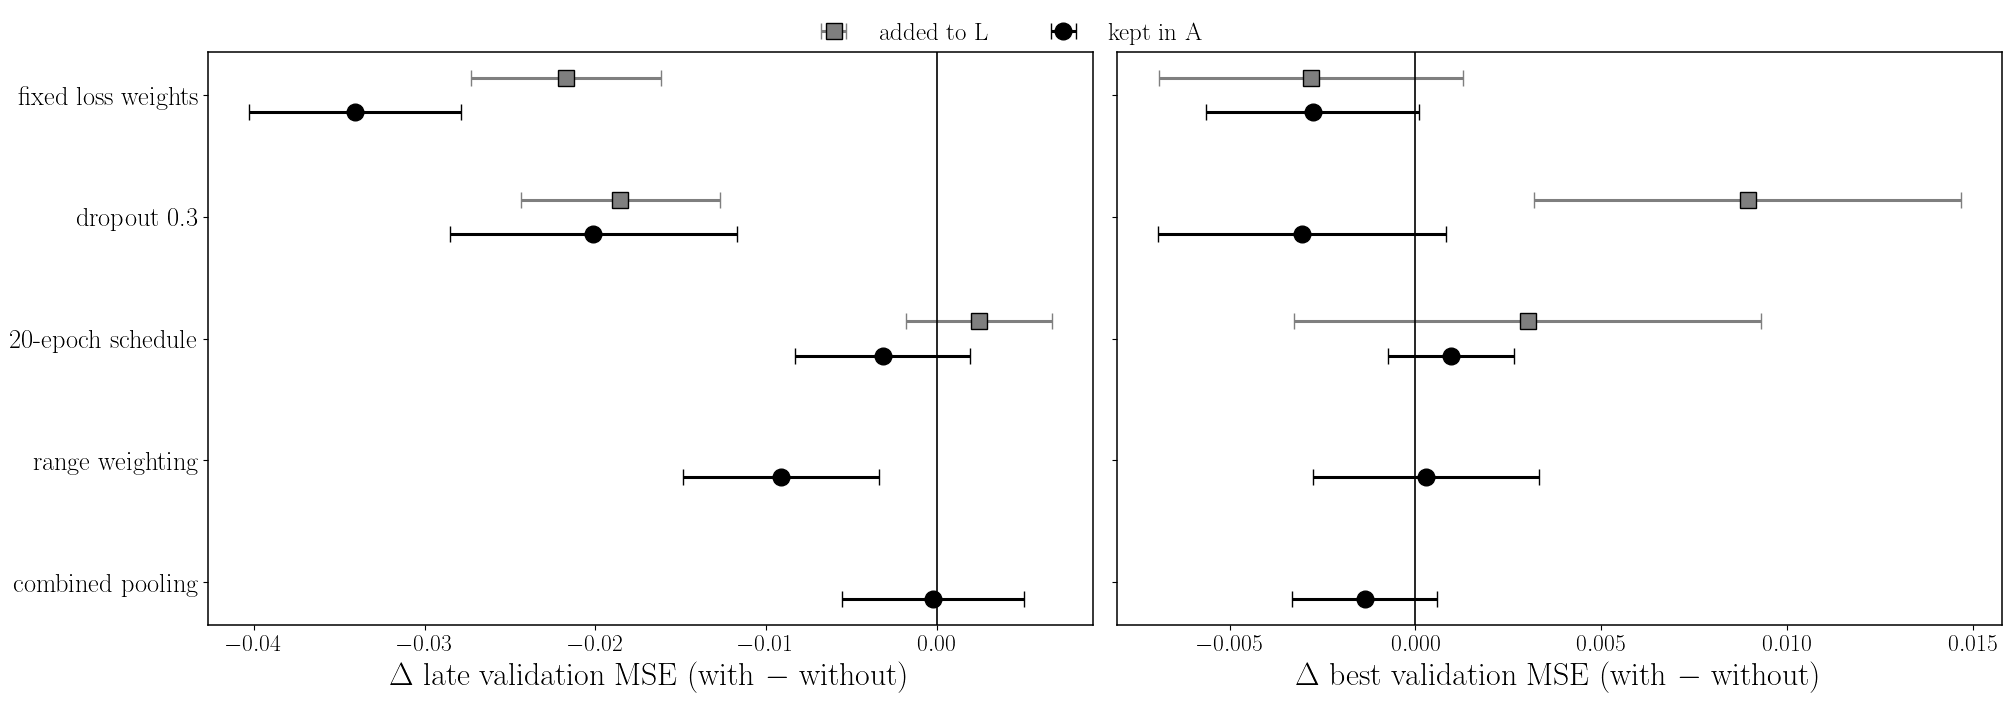

In [4]:
FACTORS = [('fixed loss weights', 'L_plus_fixed', 'A_minus_fixed'),
           ('dropout 0.3', 'L_plus_dropout', 'A_minus_dropout'),
           ('20-epoch schedule', 'L_plus_sched20', 'A_minus_sched'),
           ('range weighting', None, 'A_minus_range'),
           ('combined pooling', None, 'A_minus_combined')]
m = metrics.set_index(['config', 'seed'])
eff = []
for factor, plus, minus in FACTORS:
    for direction, with_cfg, without_cfg in [('added to L', plus, 'L_ladder'), ('kept in A', 'A_control', minus)]:
        if with_cfg is None:
            continue
        for metric in ('late', 'best'):
            d = [m.loc[(with_cfg, s), metric] - m.loc[(without_cfg, s), metric] for s in SEEDS
                 if (with_cfg, s) in m.index and (without_cfg, s) in m.index]
            eff.append(dict(factor=factor, direction=direction, metric=metric, mean=np.mean(d),
                            sd=np.std(d, ddof=1) if len(d) > 1 else np.nan, n=len(d)))
eff = pd.DataFrame(eff); eff.to_csv(EXPORT / 'factor_effects_horizon.csv', index=False)
display(eff.round(4))

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True, constrained_layout=True)
yb = np.arange(len(FACTORS))[::-1]
style = {'added to L': dict(marker='s', color='#7f7f7f', off=.14), 'kept in A': dict(marker='o', color='black', off=-.14)}
for ax, metric, xlabel in [(axes[0], 'late', r'$\Delta$ late validation MSE (with $-$ without)'),
                           (axes[1], 'best', r'$\Delta$ best validation MSE (with $-$ without)')]:
    for yv, (factor, _, _) in zip(yb, FACTORS):
        for direction, st in style.items():
            r = eff[(eff.factor == factor) & (eff.direction == direction) & (eff.metric == metric)]
            if r.empty:
                continue
            r = r.iloc[0]
            ax.errorbar(r['mean'], yv + st['off'], xerr=r.sd, fmt=st['marker'], color=st['color'], ms=12,
                        capsize=6, lw=2.2, mec='black', label=direction if yv == yb[0] or factor == 'range weighting' else None)
    ax.axvline(0, color='black', lw=1.2); ax.set_xlabel(xlabel)
axes[0].set_yticks(yb, [f for f, _, _ in FACTORS], fontsize=19)
h, l = axes[0].get_legend_handles_labels(); uniq = dict(zip(l, h))
fig.legend(uniq.values(), uniq.keys(), loc='outside upper center', ncol=2, frameon=False, fontsize=18)
save(fig, 'factor_effects')

## Loss weighting $\times$ dropout

The two settings that matter, side by side. Four cells in the control's context: A (fixed, 0.3),
A$-$fixed (shares, 0.3), A$-$dropout (fixed, 0.1) and, for shares with dropout 0.1, **L + 20-epoch schedule**.
That last cell is the closest available run (it uses whole-graph pooling instead of combined, a setting that
matters little on its own); the same 2$\times$2 in the ladder's context is L, L+fixed, L+dropout, with no
(fixed, 0.3) cell. Left: mean validation curves; right: late MSE at the common horizon.

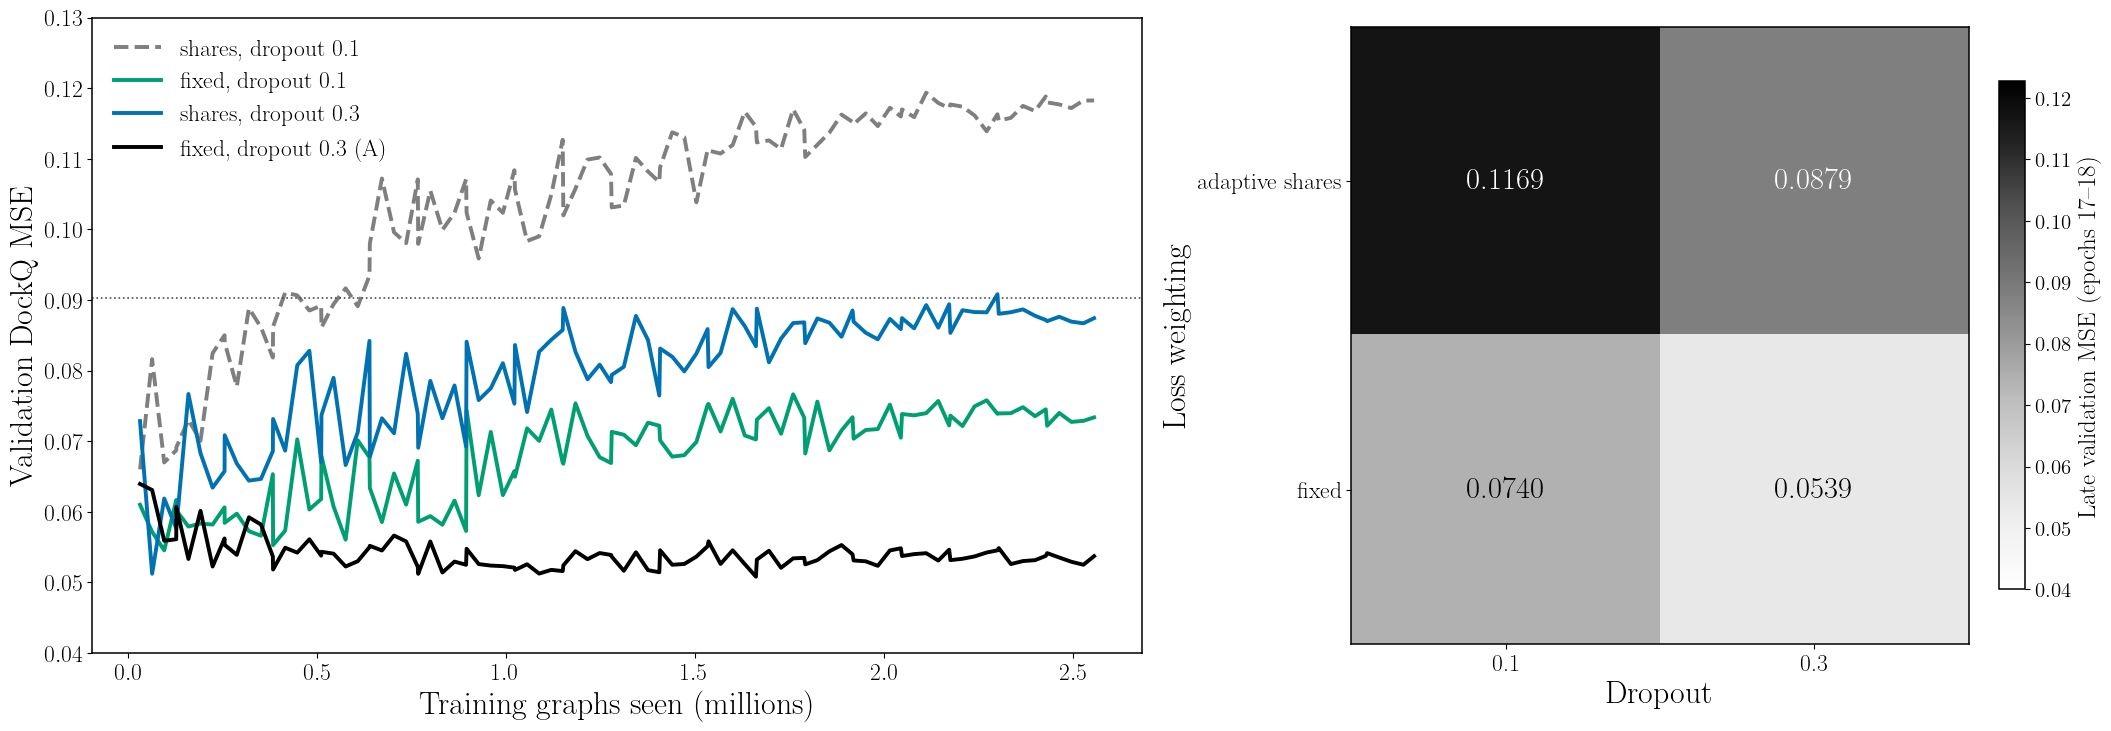

In [5]:
CELLS = {('shares', 0.1): 'L_plus_sched20', ('fixed', 0.1): 'A_minus_dropout',
         ('shares', 0.3): 'A_minus_fixed', ('fixed', 0.3): 'A_control'}
CELL_STYLE = {'L_plus_sched20': ('#7f7f7f', '--'), 'A_minus_dropout': ('#009E73', '-'),
              'A_minus_fixed': ('#0072B2', '-'), 'A_control': ('black', '-')}
CELL_LABEL = {'L_plus_sched20': 'shares, dropout 0.1', 'A_minus_dropout': 'fixed, dropout 0.1',
              'A_minus_fixed': 'shares, dropout 0.3', 'A_control': 'fixed, dropout 0.3 (A)'}
fig, (ax, axh) = plt.subplots(1, 2, figsize=(21, 7.2), gridspec_kw=dict(width_ratios=[1.7, 1]),
                              constrained_layout=True)
for cfg in CELLS.values():
    c, ls = CELL_STYLE[cfg]; mc = mean_curve(cfg)
    ax.plot(mc.x, mc.y, color=c, ls=ls, lw=2.8, label=CELL_LABEL[cfg])
ax.axhline(CONST_MSE, color='0.3', ls=':', lw=1.2)
ax.set_ylim(.04, .13); ax.set_xlabel('Training graphs seen (millions)'); ax.set_ylabel('Validation DockQ MSE')
ax.legend(frameon=False, loc='upper left', fontsize=17)
grid = np.array([[agg.loc[CELLS[(w, d)], 'late'] for d in (0.1, 0.3)] for w in ('shares', 'fixed')])
im = axh.imshow(grid, cmap='Greys', vmin=.04, vmax=grid.max() * 1.05)
for i in range(2):
    for j in range(2):
        axh.text(j, i, f'{grid[i, j]:.4f}', ha='center', va='center', fontsize=22,
                 color='white' if grid[i, j] > (.04 + grid.max()) / 2 else 'black')
axh.set_xticks([0, 1], ['0.1', '0.3']); axh.set_yticks([0, 1], ['adaptive shares', 'fixed'])
axh.set_xlabel('Dropout'); axh.set_ylabel('Loss weighting')
cb = fig.colorbar(im, ax=axh, shrink=.8); cb.set_label(f'Late validation MSE (epochs {HORIZON - 1}--{HORIZON})', fontsize=18)
cb.ax.tick_params(labelsize=15)
save(fig, 'weighting_by_dropout')

## What the adaptive weighting does

DockQ loss weight by epoch for every run that uses adaptive shares, against the fixed weight of 1. The
balancer divides each term by its running magnitude, so as the training DockQ loss shrinks its weight grows.
Dropout 0.3 keeps the training loss higher and slows (but does not stop) that escalation.

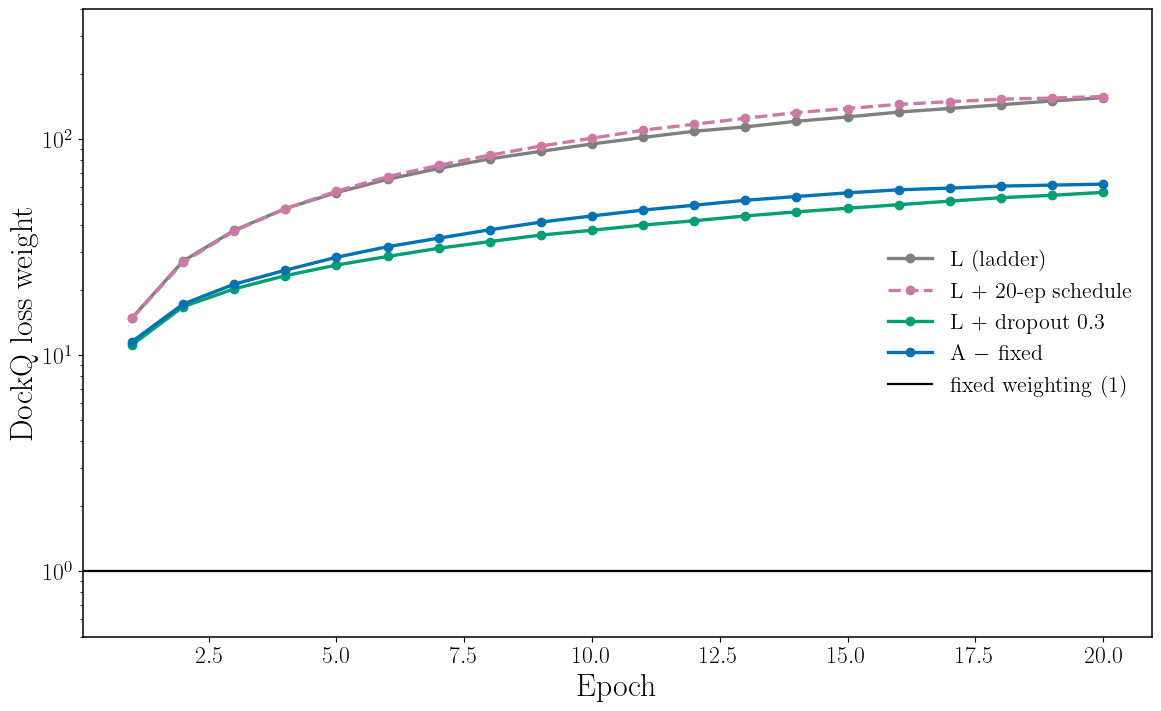

In [6]:
fig, ax = plt.subplots(figsize=(11.5, 7), constrained_layout=True)
for cfg in ['L_ladder', 'L_plus_sched20', 'L_plus_dropout', 'A_minus_fixed']:
    h = history[history.config == cfg].groupby('epoch').weight_target_mse.agg(['mean', 'std'])
    ax.plot(h.index, h['mean'], marker='o', ms=6, lw=2.4, color=COLOR[cfg], label=LABEL[cfg],
            ls='--' if cfg == 'L_plus_sched20' else '-')
ax.axhline(1, color='black', lw=1.6, label='fixed weighting (1)')
ax.set_yscale('log'); ax.set_xlabel('Epoch'); ax.set_ylabel('DockQ loss weight')
ax.set_ylim(.5, 400); ax.legend(frameon=False, loc='center right', fontsize=16)
save(fig, 'adaptive_dockq_weight')

## Training fit vs. the rise

Each point is one run: training DockQ MSE at the common horizon against how far its validation MSE has risen
from its best by then. Range-weighted runs report a weighted training MSE (mean weight 1), so read the x-axis
as approximate across that setting.

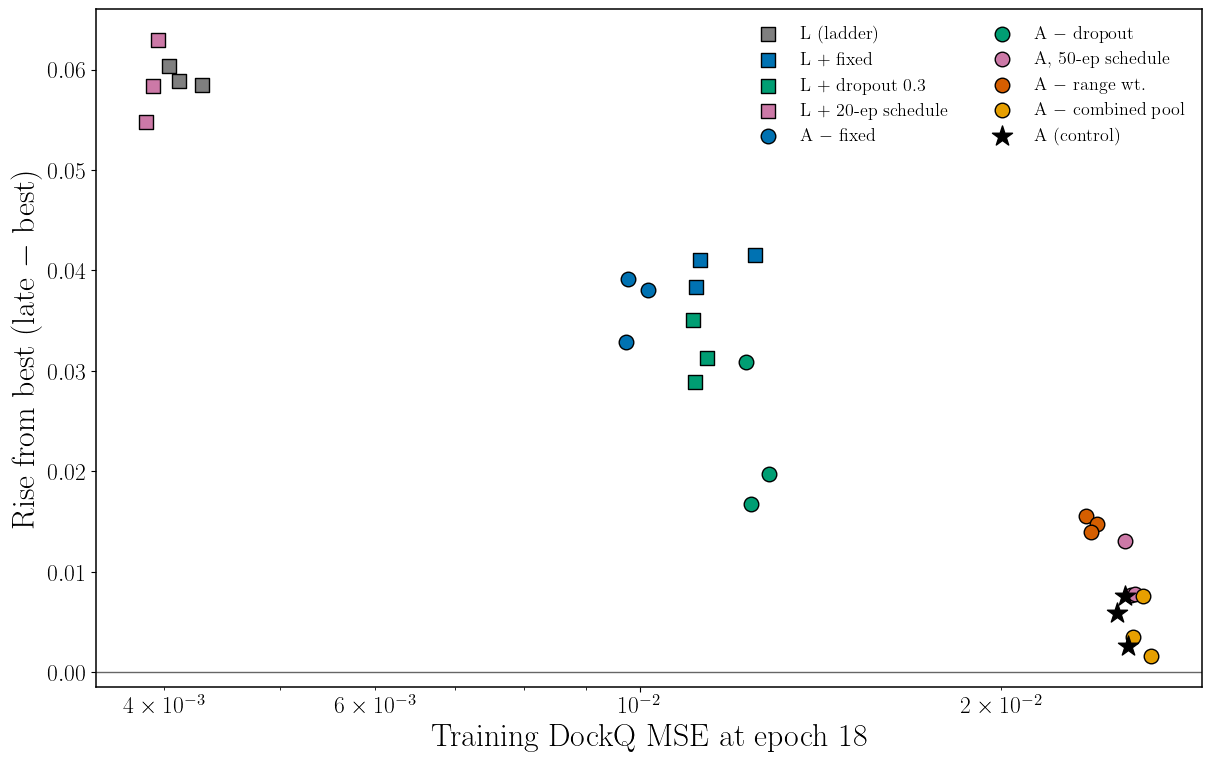

In [7]:
fig, ax = plt.subplots(figsize=(12, 7.5), constrained_layout=True)
for cfg in CONFIGS:
    r = metrics[metrics.config == cfg]
    mk = 's' if cfg.startswith('L') else ('*' if cfg == 'A_control' else 'o')
    ax.scatter(r.train_mse_h, r.rise, s=230 if mk == '*' else 110, marker=mk, color=COLOR[cfg], edgecolors='black',
               label=LABEL[cfg], zorder=5)
ax.set_xscale('log'); ax.axhline(0, color='0.4', lw=1)
ax.set_xlabel(f'Training DockQ MSE at epoch {HORIZON}'); ax.set_ylabel('Rise from best (late $-$ best)')
ax.legend(frameon=False, fontsize=13, ncol=2, loc='upper right')
save(fig, 'train_fit_vs_rise')

## How much of the old ladder gap was checkpoint resolution?

The original ladder validated once per epoch with a batch-averaged MSE. Here L is re-run with validation every
2,000 steps. Best validation MSE restricted to epoch-end validations vs. all validations, for L and A.

In [8]:
res = []
for cfg in ['L_ladder', 'A_control']:
    for seed in SEEDS:
        s = steps[(steps.config == cfg) & (steps.seed == seed)]
        res.append(dict(config=cfg, seed=seed, best_epoch_end_only=s[s.end_of_epoch == 1].val_target_mse.min(),
                        best_all_steps=s.val_target_mse.min()))
res = pd.DataFrame(res); res.to_csv(EXPORT / 'checkpoint_resolution.csv', index=False)
display(res.groupby('config')[['best_epoch_end_only', 'best_all_steps']].agg(['mean', 'std']).round(4))

best_epoch_end_only         best_all_steps        
                         mean     std           mean     std
config                                                      
A_control              0.0497  0.0021         0.0485  0.0015
L_ladder               0.0625  0.0082         0.0552  0.0020

## Finished runs: full 20 epochs

Same metrics over all 20 epochs, for configurations whose runs have finished (count shown).

In [9]:
full = metrics.dropna(subset=['late_full']).groupby('config', observed=True).agg(
    n=('seed', 'size'), best_full=('best_full', 'mean'), best_epoch_full=('best_epoch_full', 'mean'),
    late_full=('late_full', 'mean'), late_full_sd=('late_full', 'std'), rise_full=('rise_full', 'mean'),
    train_mse_full=('train_mse_full', 'mean'))
display(full.round(4)); full.to_csv(EXPORT / 'metrics_full_length.csv')

,n,best_full,best_epoch_full,late_full,late_full_sd,rise_full,train_mse_full
config,,,,,,,
L_ladder,3,0.0552,1.3333,0.1173,0.0071,0.0621,0.0039
L_plus_fixed,3,0.0524,2.3333,0.0944,0.0030,0.0420,0.0112
L_plus_dropout,3,0.0641,3.6667,0.1001,0.0055,0.0360,0.0106
L_plus_sched20,3,0.0582,1.0000,0.1174,0.0038,0.0592,0.0038
A_minus_fixed,3,0.0512,1.0000,0.0876,0.0035,0.0363,0.0097
A_minus_dropout,3,0.0515,2.0000,0.0736,0.0054,0.0221,0.0122
A_minus_sched,3,0.0475,8.6667,0.0564,0.0058,0.0089,0.0249
A_minus_range,3,0.0482,5.0000,0.0626,0.0012,0.0145,0.0234
A_minus_combined,2,0.0498,4.5000,0.0553,0.0015,0.0056,0.0258


## Checkpoint quality

What the best checkpoint of each configuration is worth beyond MSE: macro within-target Spearman $\rho$ and
mean top-1 true DockQ on the 12 validation targets, plus the mean error on high-quality decoys (true DockQ
0.8--1). Finished runs only; seed mean $\pm$ SD.

,n,macro_rho,rho_sd,top1,top1_sd,high_bias,macro_target_mse
config,,,,,,,
L_ladder,3,0.7013,0.0183,0.4826,0.0909,-0.3335,0.0568
L_plus_fixed,3,0.7000,0.0246,0.5280,0.0696,-0.3502,0.0554
L_plus_dropout,3,0.6959,0.0279,0.4654,0.0645,-0.4198,0.0667
L_plus_sched20,3,0.7015,0.0020,0.4297,0.0680,-0.3464,0.0596
A_minus_fixed,3,0.7078,0.0100,0.4513,0.0320,-0.3668,0.0527
A_minus_dropout,3,0.6893,0.0083,0.4689,0.0926,-0.3402,0.0530
A_minus_sched,3,0.7068,0.0236,0.4851,0.0341,-0.3061,0.0507
A_minus_range,3,0.7094,0.0224,0.4897,0.0505,-0.3317,0.0504
A_minus_combined,2,0.7058,0.0009,0.5607,0.0021,-0.3298,0.0515


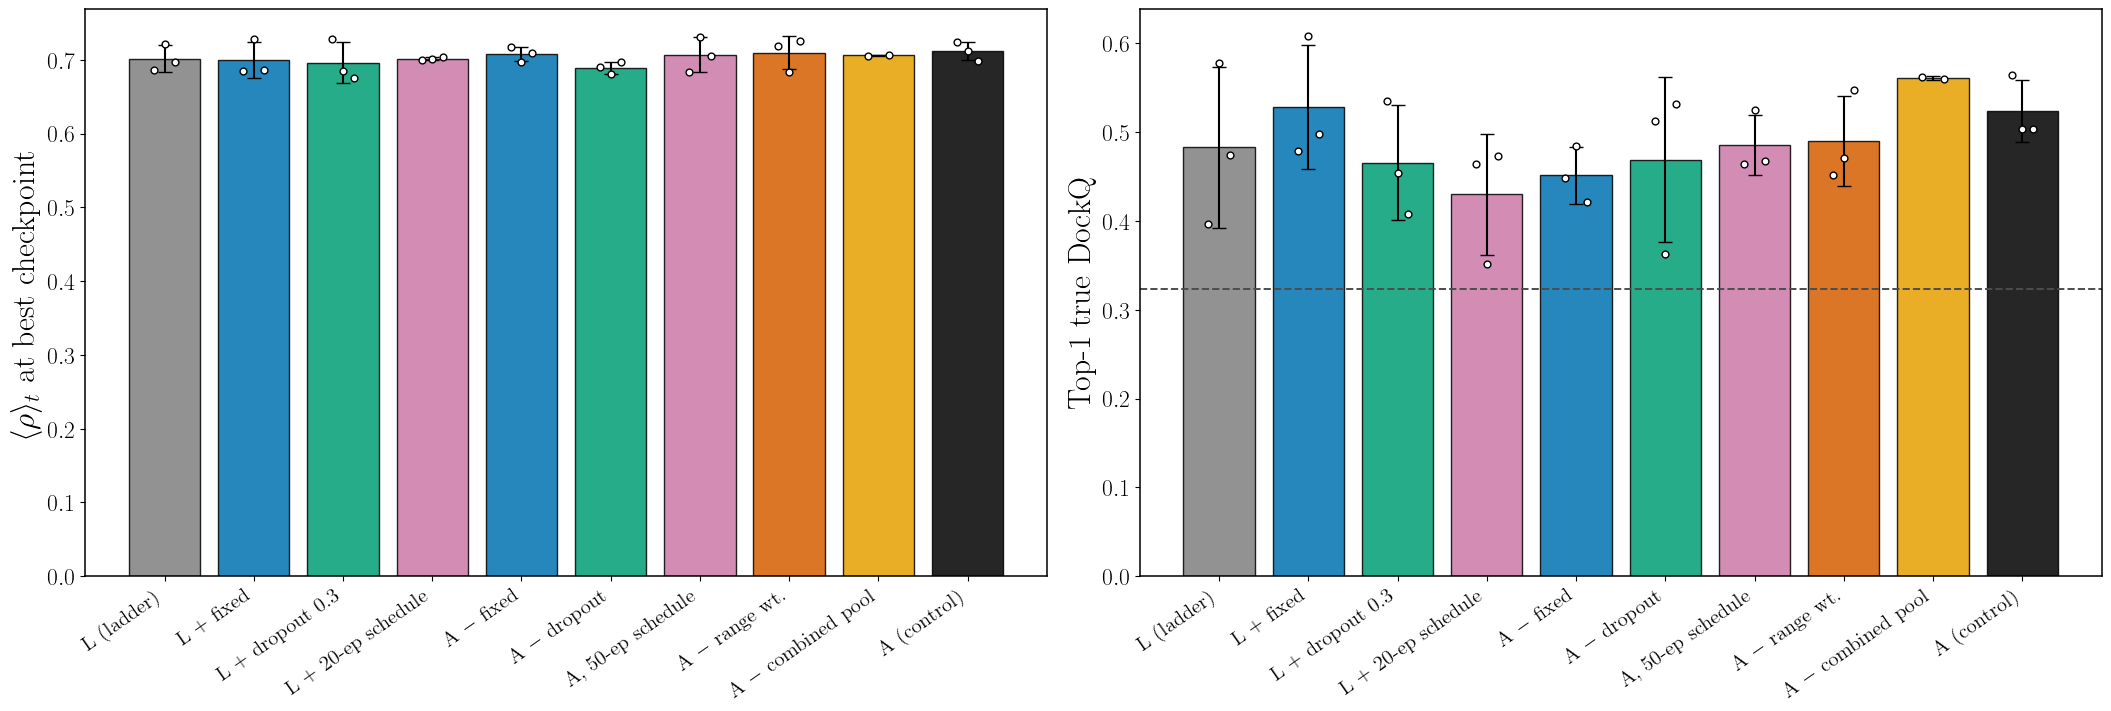

In [10]:
from scipy.stats import spearmanr
import json
q = []
for (config, seed), pr in predictions.items():
    t = pr.groupby('target_id')[['graph_name', 'true_target', 'predicted_target']].apply(lambda g: pd.Series(dict(
        rho=spearmanr(g.true_target, g.predicted_target).statistic,
        top1=g.true_target.to_numpy()[np.lexsort((g.graph_name.to_numpy(), -g.predicted_target.to_numpy()))[0]])))
    rep_ = json.loads((run_dir(config, seed) / 'prediction_metrics.json').read_text())['validation']
    q.append(dict(config=config, seed=seed, macro_rho=t.rho.mean(), top1=t.top1.mean(),
                  high_bias=rep_['bins'][4]['bias'], macro_target_mse=rep_['macro_target_mse']))
q = pd.DataFrame(q)
quality = q.groupby('config').agg(n=('seed', 'size'), macro_rho=('macro_rho', 'mean'), rho_sd=('macro_rho', 'std'),
    top1=('top1', 'mean'), top1_sd=('top1', 'std'), high_bias=('high_bias', 'mean'),
    macro_target_mse=('macro_target_mse', 'mean')).reindex(CONFIGS).dropna(how='all')
quality.to_csv(EXPORT / 'checkpoint_quality.csv'); display(quality.round(4))

fig, axes = plt.subplots(1, 2, figsize=(21, 7), constrained_layout=True)
xq = np.arange(len(quality))
for ax, col, sd, ylabel in [(axes[0], 'macro_rho', 'rho_sd', r'$\langle\rho\rangle_t$ at best checkpoint'),
                            (axes[1], 'top1', 'top1_sd', 'Top-1 true DockQ')]:
    ax.bar(xq, quality[col], yerr=quality[sd], capsize=5, color=[COLOR[c] for c in quality.index],
           edgecolor='black', alpha=.85)
    for i, c in enumerate(quality.index):
        sv = q[q.config == c][col].to_numpy()
        ax.scatter(i + np.linspace(-.12, .12, len(sv)), sv, s=24, zorder=6, facecolors='white', edgecolors='black')
    ax.set_xticks(xq, [LABEL[c] for c in quality.index], rotation=35, ha='right', fontsize=15)
    ax.set_ylabel(ylabel)
axes[1].axhline(reference.groupby('target_id').true_target.mean().mean(), color='0.3', ls='--', lw=1.4)
save(fig, 'checkpoint_quality')

## Is anything still drifting at the end?

The question for long training: over the second half of the run (epochs 10--20), is validation MSE still
rising, flat or falling? Slope of a straight-line fit to all validations in that window, in MSE per million
training graphs seen. Finished runs only; bars are seed means, dots seeds.

,mean,std,size
config,,,
L_ladder,0.00964,0.00351,3
L_plus_fixed,0.00689,0.00269,3
L_plus_dropout,0.00603,0.00495,3
L_plus_sched20,0.00871,0.00094,3
A_minus_fixed,0.00538,0.00096,3
A_minus_dropout,0.00247,0.00142,3
A_minus_sched,0.00187,0.00022,3
A_minus_range,0.00223,0.00268,3
A_minus_combined,-0.00008,0.00008,2


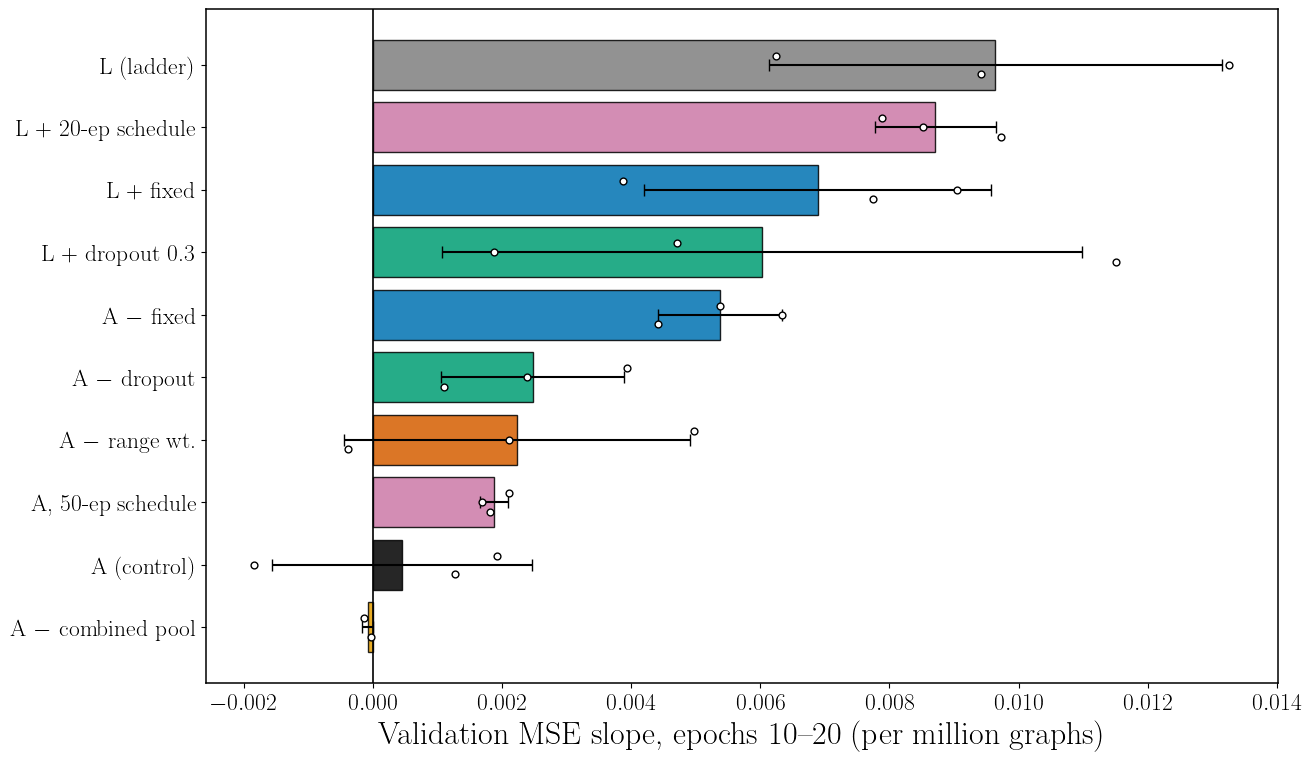

In [11]:
drift = []
for (config, seed), s in steps.groupby(['config', 'seed']):
    if not status[(status.config == config) & (status.seed == seed)].complete.iloc[0]:
        continue
    w = s[s.epoch > 10]
    drift.append(dict(config=config, seed=seed, slope=np.polyfit(w.graphs_seen_M, w.val_target_mse, 1)[0]))
drift = pd.DataFrame(drift)
dm = drift.groupby('config').slope.agg(['mean', 'std', 'size']).reindex(CONFIGS).dropna()
dm.to_csv(EXPORT / 'late_drift.csv'); display(dm.round(5))
order = dm.sort_values('mean').index
fig, ax = plt.subplots(figsize=(13, 7.5), constrained_layout=True)
yd = np.arange(len(order))
ax.barh(yd, dm.loc[order, 'mean'], xerr=dm.loc[order, 'std'], color=[COLOR[c] for c in order], edgecolor='black',
        alpha=.85, capsize=4)
for i, c in enumerate(order):
    sv = drift[drift.config == c].slope.to_numpy()
    ax.scatter(sv, i + np.linspace(-.15, .15, len(sv)), s=24, zorder=6, facecolors='white', edgecolors='black')
ax.axvline(0, color='black', lw=1.2)
ax.set_yticks(yd, [LABEL[c] for c in order], fontsize=17)
ax.set_xlabel('Validation MSE slope, epochs 10--20 (per million graphs)')
save(fig, 'late_drift')

## Observed vs predicted DockQ on the validation set

Each panel pools the best checkpoints of all finished seeds of one configuration (12 validation targets,
14,155 decoys per seed). Shading is the log count of decoys; the dashed diagonal is perfect agreement, the
dotted lines mark the CAPRI thresholds (0.23 acceptable, 0.49 medium, 0.80 high) on both axes, and the
white line is the mean prediction in bins of observed DockQ. Points far below the diagonal at the right are
high-quality decoys predicted too low. These are best checkpoints, so for L-type configurations they come
from epoch 1--2.

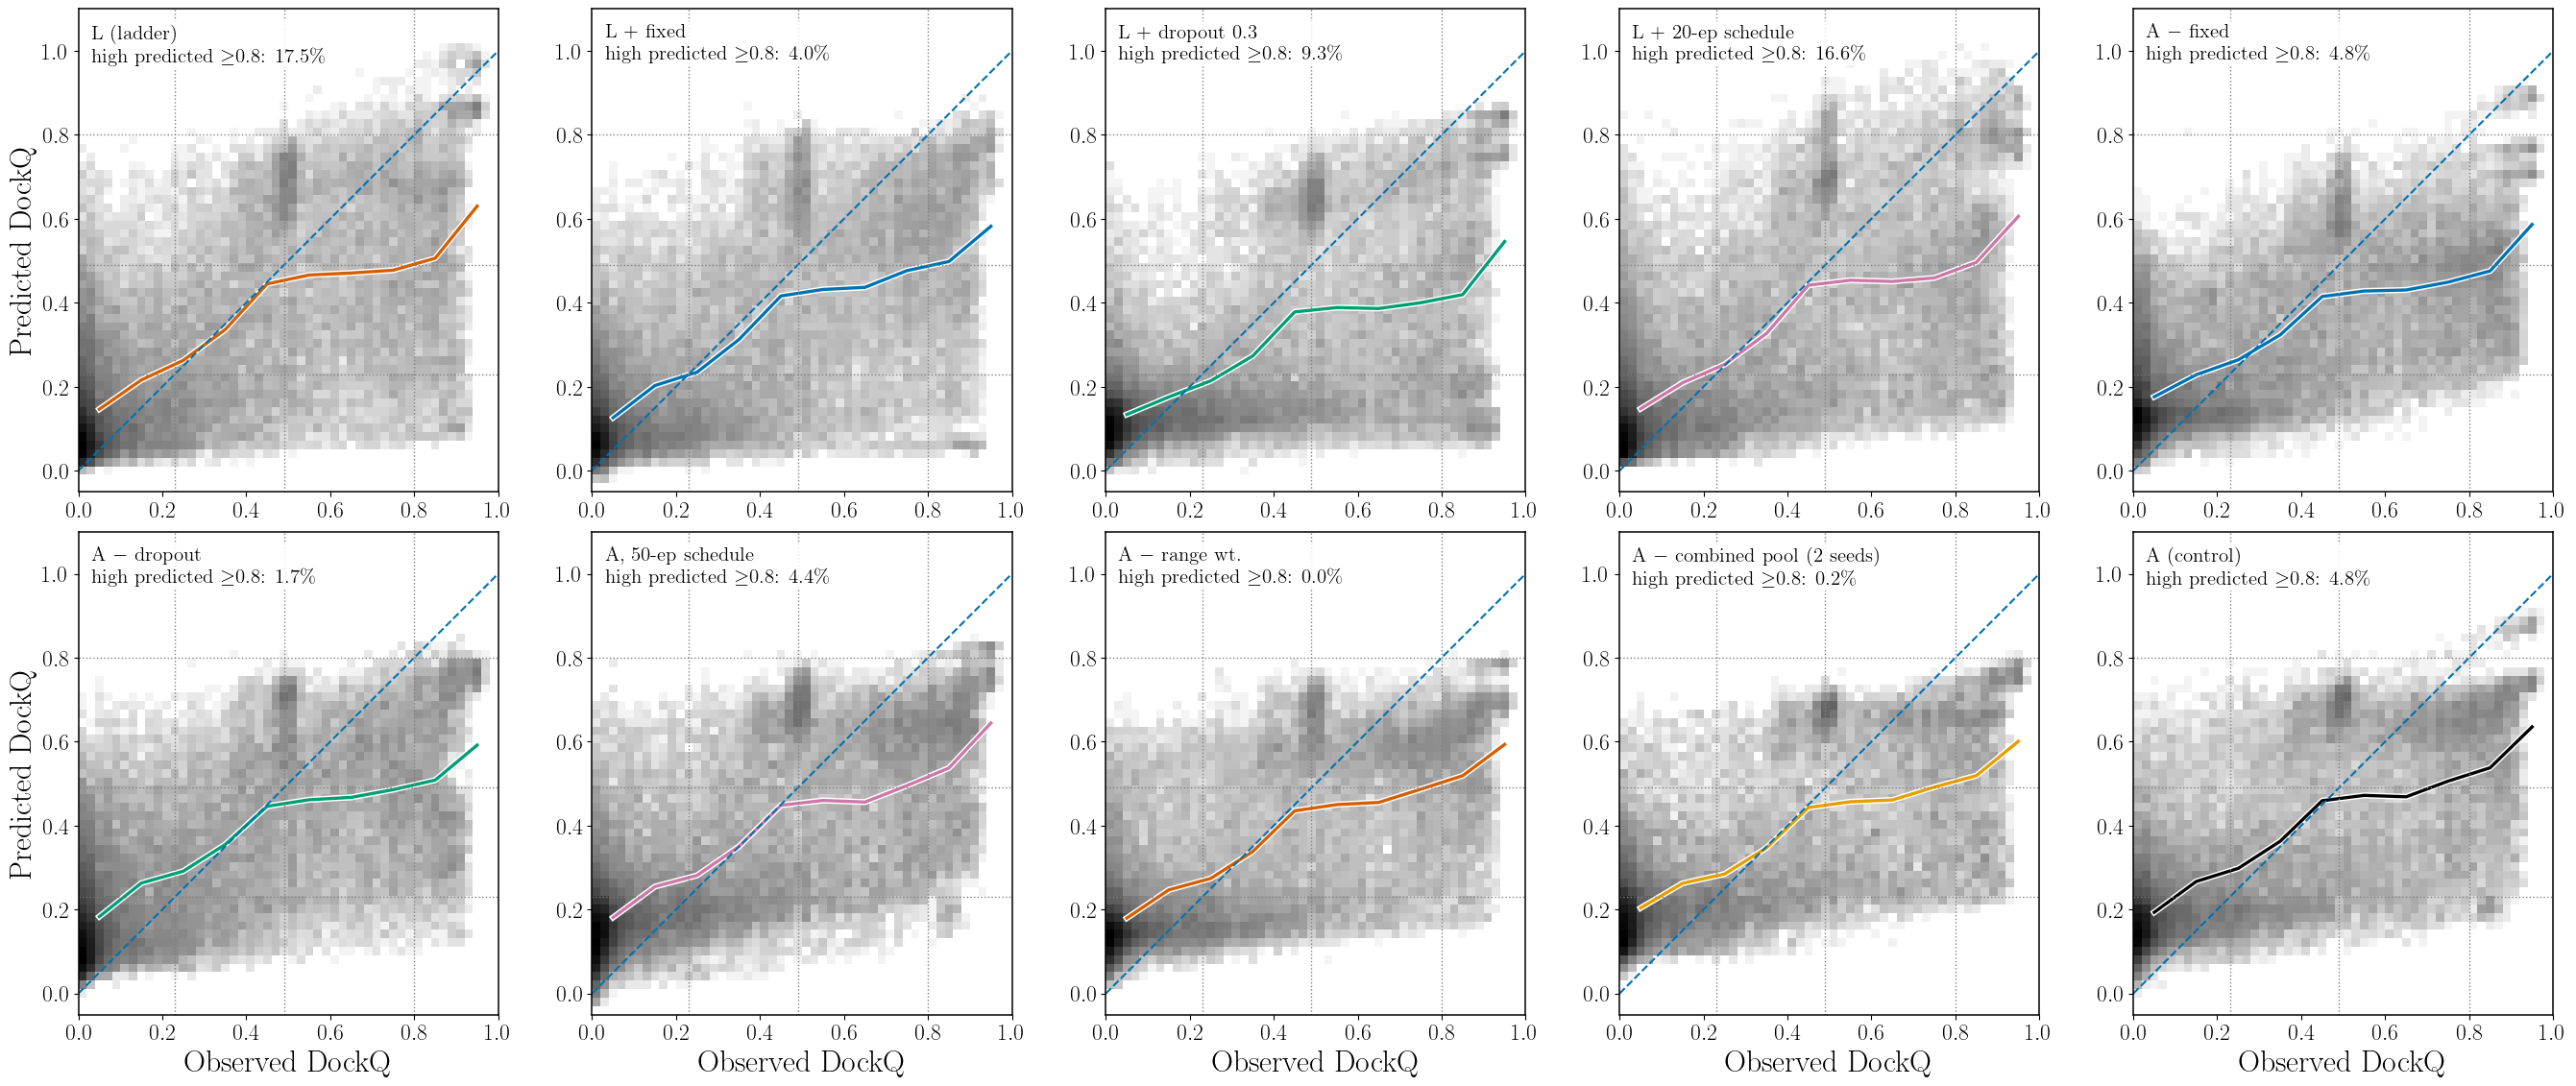

In [12]:
from matplotlib.colors import LogNorm
CAPRI = (0.23, 0.49, 0.80)
cfgs = [c for c in CONFIGS if any(k[0] == c for k in predictions)]
ncols = 5; nrows = int(np.ceil(len(cfgs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 5.6 * nrows), sharex=True, sharey=True,
                         constrained_layout=True)
edges = np.linspace(0, 1, 11)
for ax, cfg in zip(axes.flat, cfgs):
    pr = pd.concat([v for k, v in predictions.items() if k[0] == cfg])
    h = ax.hist2d(pr.true_target, pr.predicted_target.clip(-.05, 1.1), bins=[np.linspace(0, 1, 51), np.linspace(-.05, 1.1, 58)],
                  cmap='Greys', norm=LogNorm(vmin=1), rasterized=True)
    mids = (edges[:-1] + edges[1:]) / 2
    means = pr.groupby(pd.cut(pr.true_target, edges, include_lowest=True), observed=False).predicted_target.mean()
    ax.plot(mids, means.to_numpy(), color='white', lw=4.5); ax.plot(mids, means.to_numpy(), color=COLOR[cfg] if cfg != 'L_ladder' else '#D55E00', lw=2.4)
    ax.plot([0, 1], [0, 1], color='#0072B2', ls='--', lw=1.5)
    for t in CAPRI:
        ax.axvline(t, color='0.5', ls=':', lw=1); ax.axhline(t, color='0.5', ls=':', lw=1)
    n_seeds = sum(k[0] == cfg for k in predictions)
    hi = pr.true_target >= .8
    ax.text(.03, .97, LABEL[cfg] + (f' ({n_seeds} seeds)' if n_seeds < 3 else '') +
            '\n' + rf'high predicted $\geq$0.8: {(pr.predicted_target[hi] >= .8).mean() * 100:.1f}\%',
            transform=ax.transAxes, va='top', fontsize=15, bbox=dict(facecolor='white', edgecolor='none', alpha=.85, pad=2))
    ax.set(xlim=(0, 1), ylim=(-.05, 1.1)); ax.set_aspect('equal', adjustable='box')
    ax.tick_params(labelbottom=True, labelleft=True)
for ax in axes.flat[len(cfgs):]: ax.set_visible(False)
for ax in axes[-1]: ax.set_xlabel('Observed DockQ')
for ax in axes[:, 0]: ax.set_ylabel('Predicted DockQ')
save(fig, 'observed_vs_predicted_by_config')

### Per target: ladder recipe vs control

All 12 validation targets for seed 17, L (orange) against A (black), at each run's best checkpoint. Shared
axes; dashed line is perfect agreement; dotted lines are CAPRI thresholds. The in-panel numbers are
within-target Spearman $\rho$ for each.

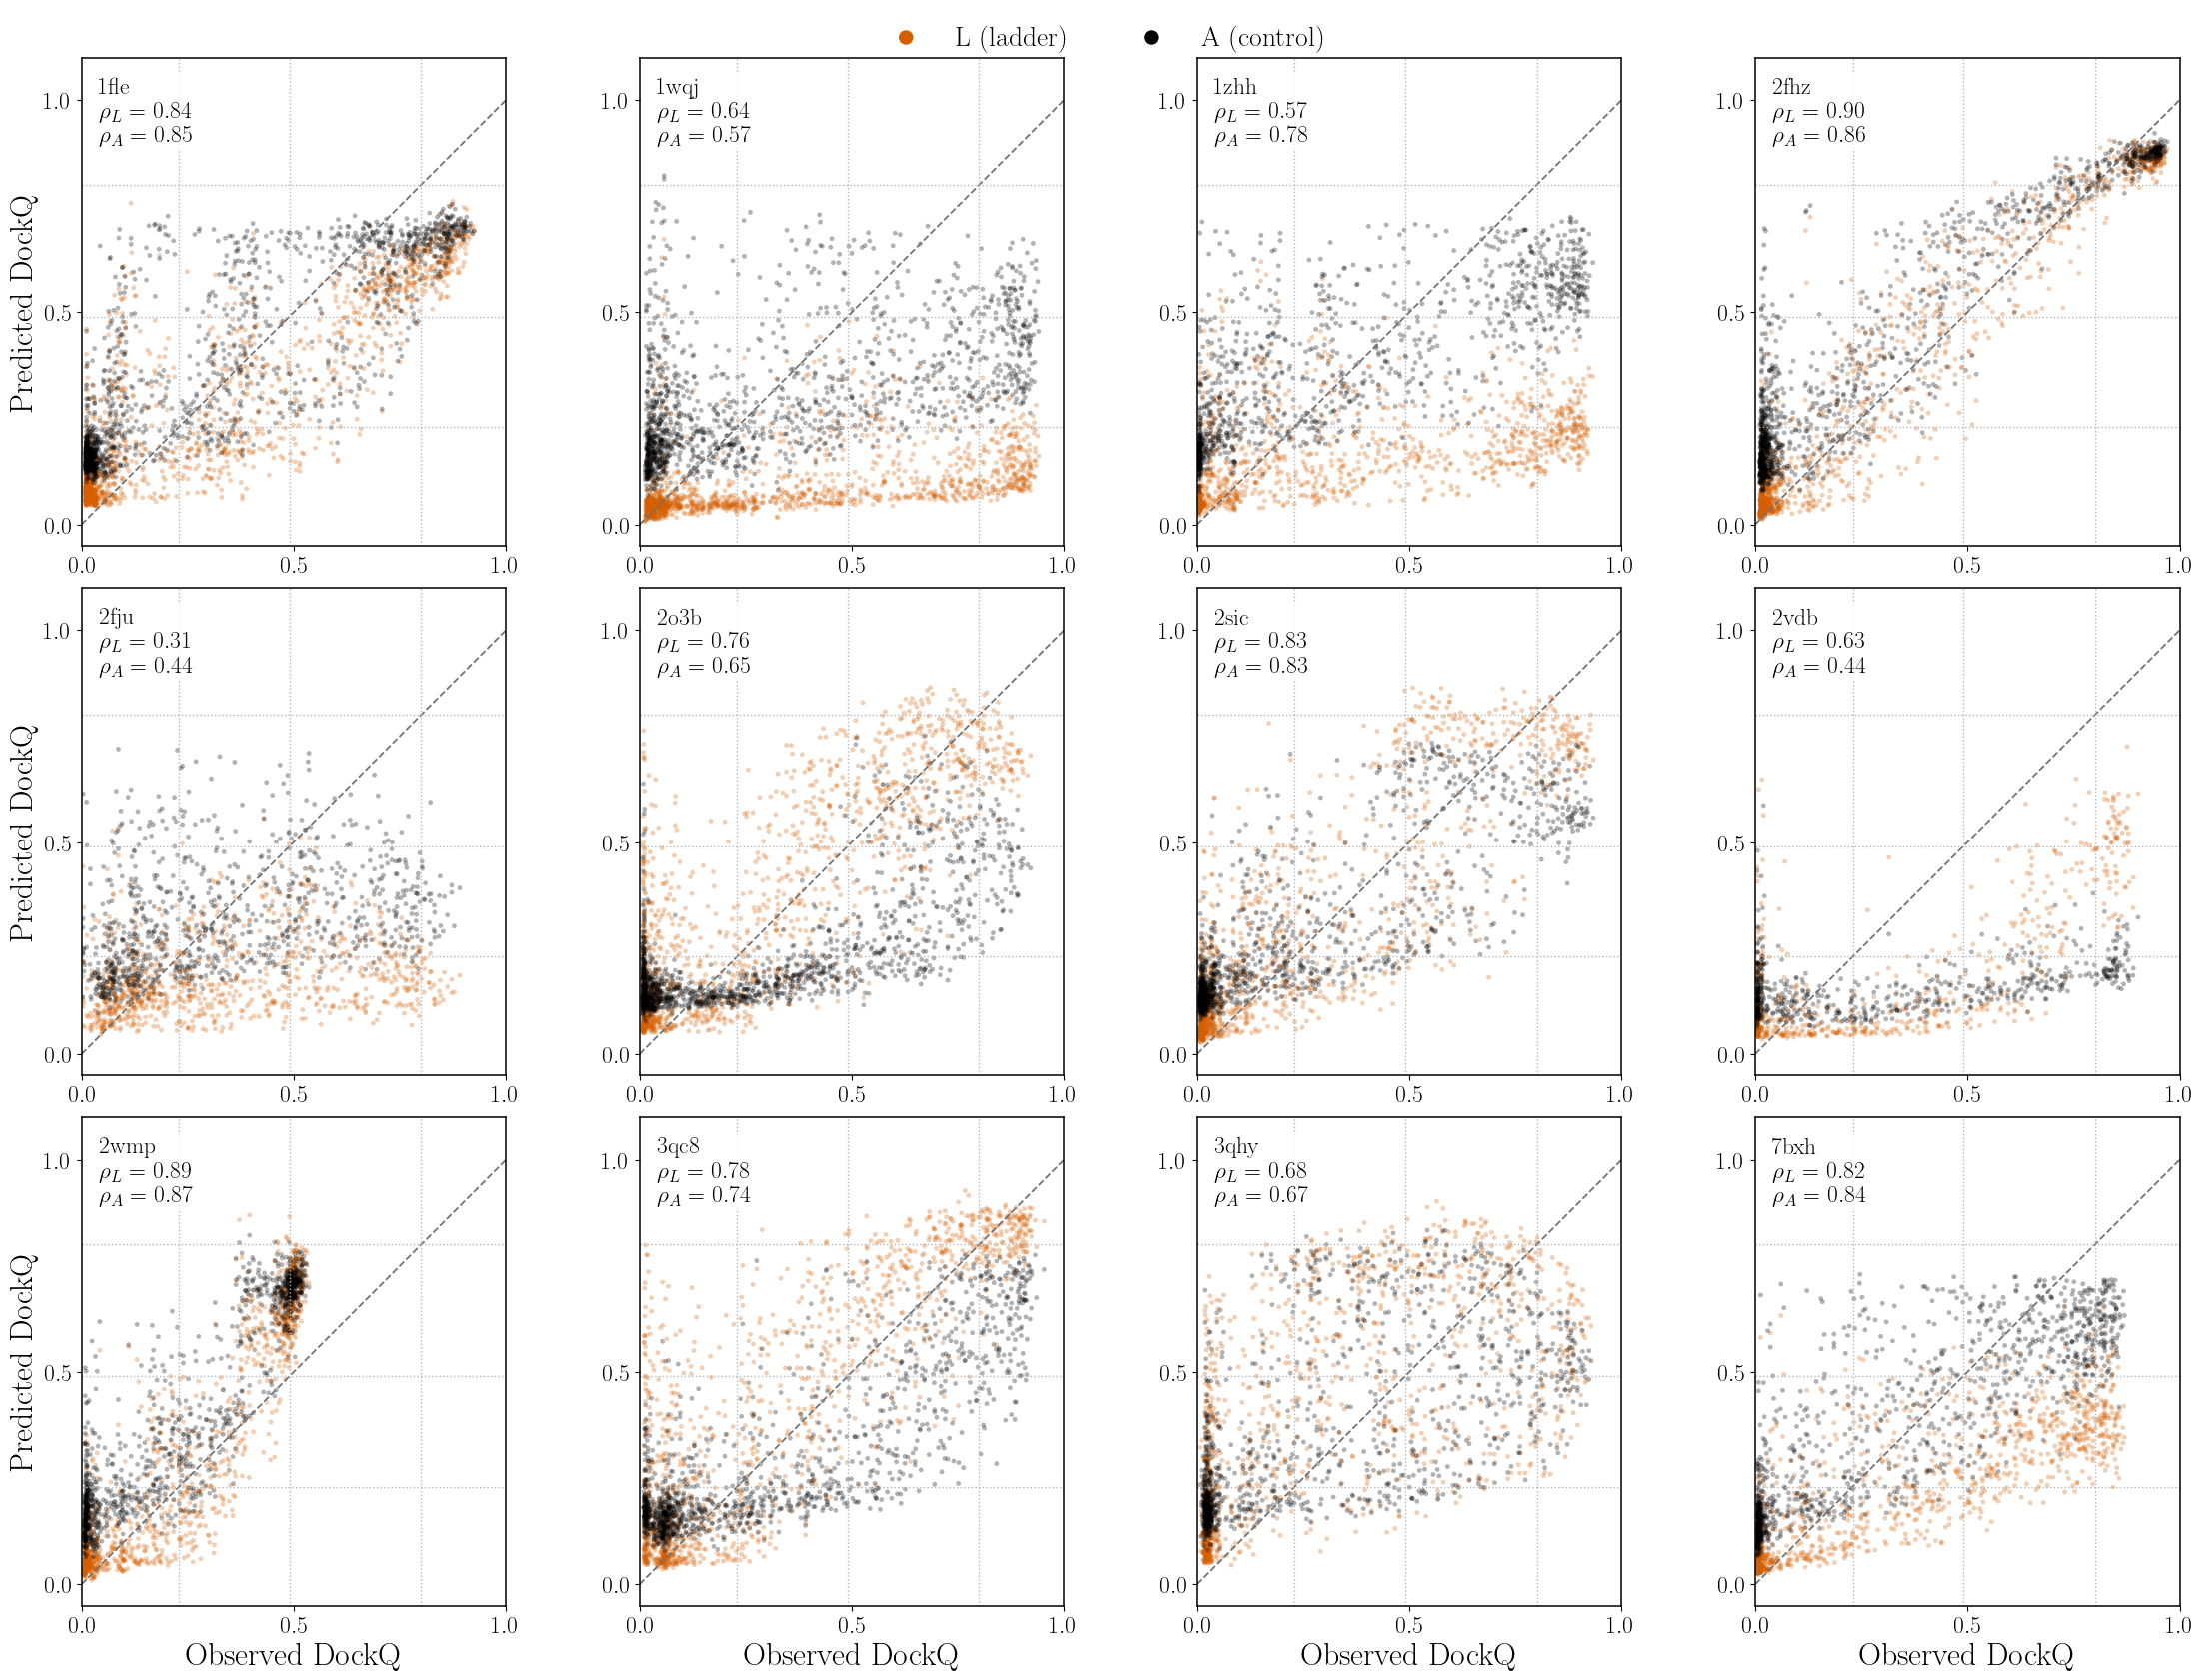

In [13]:
PANEL_SEED = 17
pair = [('L_ladder', '#D55E00'), ('A_control', 'black')]
targets = sorted(reference.target_id.unique())
ncols = 4; nrows = int(np.ceil(len(targets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 5.6 * nrows), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, t in zip(axes.flat, targets):
    rhos = {}
    for cfg, color in pair:
        g = predictions[cfg, PANEL_SEED]; g = g[g.target_id == t]
        rhos[cfg] = spearmanr(g.true_target, g.predicted_target).statistic
        ax.scatter(g.true_target, g.predicted_target, s=12, alpha=.3, color=color, edgecolors='none', rasterized=True,
                   label=LABEL[cfg])
    ax.plot([0, 1], [0, 1], color='0.45', ls='--', lw=1.3)
    for c in CAPRI:
        ax.axvline(c, color='0.7', ls=':', lw=1); ax.axhline(c, color='0.7', ls=':', lw=1)
    ax.text(.04, .96, t + '\n' + rf"$\rho_L={rhos['L_ladder']:.2f}$" + '\n' + rf"$\rho_A={rhos['A_control']:.2f}$",
            transform=ax.transAxes, va='top', fontsize=17, bbox=dict(facecolor='white', edgecolor='none', alpha=.8, pad=2))
    ax.set(xlim=(0, 1), ylim=(-.05, 1.1)); ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([0, .5, 1]); ax.set_yticks([0, .5, 1]); ax.tick_params(labelbottom=True, labelleft=True)
for ax in axes.flat[len(targets):]: ax.set_visible(False)
for ax in axes[-1]: ax.set_xlabel('Observed DockQ')
for ax in axes[:, 0]: ax.set_ylabel('Predicted DockQ')
leg = fig.legend(*axes.flat[0].get_legend_handles_labels(), loc='outside upper center', ncol=2, frameon=False,
                 fontsize=20, markerscale=3)
for hnd in leg.legend_handles: hnd.set_alpha(1)
save(fig, f'observed_vs_predicted_per_target_seed{PANEL_SEED}')

## Readout

In [14]:
e = eff.set_index(['factor', 'direction', 'metric'])
def fx(f, d, m='late'):
    if (f, d, m) not in e.index: return 'not tested'
    r = e.loc[(f, d, m)]
    return f"{r['mean']:+.4f} ± {r.sd:.4f} (n={int(r.n)})"
lines = [f'Status: {done}/{len(new)} ablation runs complete; common horizon {HORIZON} epochs.', '',
         '| setting | Δ late MSE, added to L | Δ late MSE, kept in A |', '|---|---|---|']
lines += [f'| {f} | {fx(f, "added to L")} | {fx(f, "kept in A")} |' for f, _, _ in FACTORS]
lines += ['', '| config | best | late | rise | best epoch |', '|---|---|---|---|---|']
lines += [f"| {c} | {agg.loc[c, 'best']:.4f} | {agg.loc[c, 'late']:.4f} | {agg.loc[c, 'rise']:+.4f} | "
          f"{agg.loc[c, 'best_epoch']:.1f} |" for c in CONFIGS]
text = '\n'.join(lines)
display(Markdown(text)); (EXPORT / 'readout.md').write_text(text)

Status: 26/27 ablation runs complete; common horizon 18 epochs.

| setting | Δ late MSE, added to L | Δ late MSE, kept in A |
|---|---|---|
| fixed loss weights | -0.0217 ± 0.0056 (n=3) | -0.0341 ± 0.0062 (n=3) |
| dropout 0.3 | -0.0185 ± 0.0058 (n=3) | -0.0201 ± 0.0084 (n=3) |
| 20-epoch schedule | +0.0025 ± 0.0043 (n=3) | -0.0032 ± 0.0051 (n=3) |
| range weighting | not tested | -0.0091 ± 0.0058 (n=3) |
| combined pooling | not tested | -0.0002 ± 0.0053 (n=3) |

| config | best | late | rise | best epoch |
|---|---|---|---|---|
| L_ladder | 0.0552 | 0.1144 | +0.0592 | 1.3 |
| L_plus_fixed | 0.0524 | 0.0927 | +0.0403 | 2.3 |
| L_plus_dropout | 0.0641 | 0.0958 | +0.0317 | 3.7 |
| L_plus_sched20 | 0.0582 | 0.1169 | +0.0587 | 1.0 |
| A_minus_fixed | 0.0512 | 0.0879 | +0.0367 | 1.0 |
| A_minus_dropout | 0.0515 | 0.0740 | +0.0225 | 2.0 |
| A_minus_sched | 0.0475 | 0.0570 | +0.0095 | 8.7 |
| A_minus_range | 0.0482 | 0.0630 | +0.0148 | 5.0 |
| A_minus_combined | 0.0498 | 0.0541 | +0.0042 | 7.3 |
| A_control | 0.0485 | 0.0539 | +0.0054 | 9.3 |

1052

## Interpretation

Numbers quoted are from the run with 26/27 runs finished (common horizon 18 epochs); the one unfinished run is
A $-$ combined pool seed 27 at epoch 18.

- **The rise is reproduced and explained.** Re-run under the new measurement, L is best at epoch 1--2
  (0.055) and climbs to $\sim$0.117 by epoch 20; A is best around epoch 9 (0.0485) and ends near 0.053.
- **Two settings account for most of it: fixed loss weights and dropout 0.3.** Both directions agree for
  both. Fixed weights lower late MSE by 0.022 (added to L) and 0.034 (kept in A); dropout 0.3 by 0.019 and
  0.020. In the weighting $\times$ dropout grid (rise from best: 0.059 with neither), fixed weights alone cut the
  rise to 0.023 and dropout alone to 0.037: fixed weights alone remove about two thirds of it, dropout alone
  about two fifths, and together nearly all of it (0.005). The effects are only mildly
  sub-additive, so A needs both.
- **Mechanism.** Under adaptive shares the DockQ weight escalates (to $\sim$160 by epoch 20 with dropout 0.1,
  $\sim$60 with dropout 0.3) as the training DockQ loss shrinks; that and low dropout both let the training
  targets be fit very tightly, and across every run the tighter the training fit, the larger the rise.
- **Range weighting is a real but smaller third factor:** removing it from A raises late MSE by $\sim$0.009
  and the rise from 0.005 to 0.015.
- **Schedule and pooling are not causes.** Neither changes late MSE measurably in either direction.
  A with the 50-epoch schedule even has the lowest best MSE of any configuration (0.0475 vs 0.0485) and
  drifts only slightly more than A, which matters for planning longer runs.
- **Ranking at the best checkpoint barely differs.** Macro within-target $\rho$ is 0.69--0.71 for every
  configuration and top-1 differences are within seed noise. These settings change calibration (A has the
  smallest high-DockQ under-prediction) and, above all, whether the best value is kept, not how decoys are
  ranked at the best point.
- **At the end of training A is flat** (late slope $\approx 0$); with the 50-epoch schedule it still creeps
  up slowly, and every configuration missing fixed weights or dropout is still rising.
- **Dropout 0.3 is not free at the best checkpoint in L's context:** added to L it worsens the best MSE
  (0.064 vs 0.055) even though it reduces the rise. In A's context (fixed weights) it does not.
- **Most of the old "best MSE" gap was measurement.** With validation every 2,000 steps L's best is 0.055,
  not 0.072; A is $\sim$12\% better at its best. The decisive difference between the recipes is that A
  **keeps** its best value.
- **Even A is not yet a "train for 200 epochs" recipe.** It reaches its best around 1M graphs and then sits
  roughly flat while its learning rate anneals; with a longer schedule it drifts up slightly. Further gains in
  long-run stability will have to come from limiting training fit further (e.g. stronger reconstruction
  weight, weight decay, EMA), which is the next experiment to design.
- Caveats: three seeds and 12 validation targets; one 2$\times$2 cell is approximate (pooling differs, a
  setting with no measurable effect). The test split is untouched.